# MEL city bikes ETL

This notebook is part of data engineering project concentrated on building **ETL pipeline** using open datasets from the **detaMEL/Lille Metropole Open Data**.

---

## Table of Contents
1. Introduction
2. Star Schema Design
3. Tables Specification
4. Next Steps

## 1. Introduction

This notebook focuses on defining the **conceptual and logical data model** based on insights gathered during the initial exploratory data analysis.

---

**Objective**

The main objective of this stage is to design a **draft star schema**, including the separation between **dimension** and **fact** tables, identify and validate the **primary keys (PK)** and **foreign keys (FK)** required to establish relationships between tables and evaluate column relevance and mark potential fields for removal, based on redundancy, lack of analytical value, or weak referential usability.

## 2. Star Schema Design

The analytical model for this dataset is based on a **Star Schema architecture**, which enables fast query execution, simplified joins, and high compatibility with BI tools such as **Power BI**.

The central analytical events are stored in **fact tables**, while descriptive information providing context to the facts is stored in **dimension tables**.

**One-to-many relations** are established: a single dimension attribute is able to describe multiple fact events.

It was decided to preserve dimension tables without a connection with a fact table - as **standalone lookup structures**, to allow for future integration once additional identifiers or keys are introduced

In [5]:
from pathlib import Path
from IPython.display import Image, display

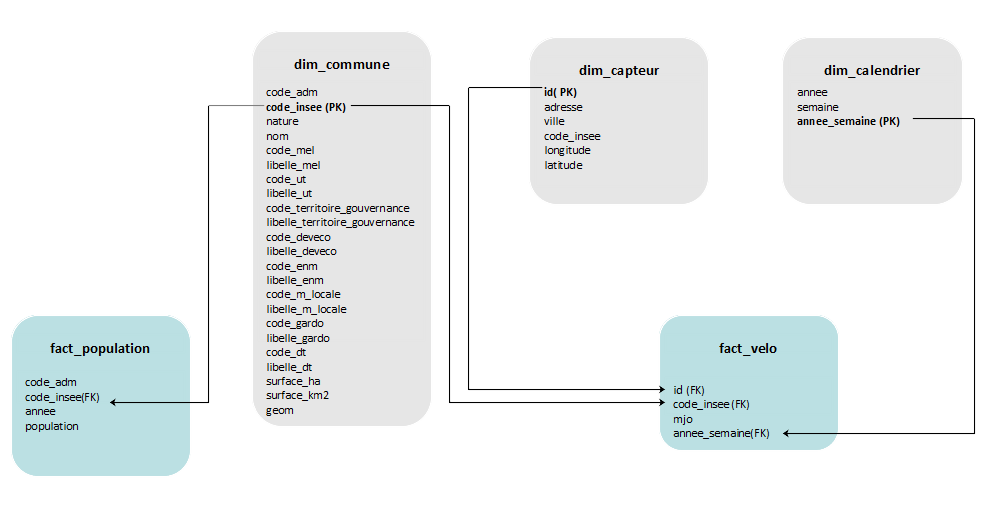

In [6]:
img_path = Path().resolve().parent / "images/star_schema_draft.png"
display(Image(filename=img_path))

## 3. Tables Specification

### Fact Tables

During initial exploratory analysis **two fact tables** were identified:

1. `fact_velo` -  provides aggregated information about bikes detected by electromagnetic sensors embedded in the road surface.
- **Foreign keys:** `id`, `code_insee`, `annee_semaine`
- These keys establish one-to-many relationships with the corresponding primary keys in the dimension tables:
    - `id` → `dim_capteur`
    - `code_insee` → `dim_commune`
    - `annee_semaine` → `dim_calendrier`

2. `fact_population` - contains information about population size changes over time.
- **Foreign key:** `code_insee`
- This key links to the `code_insee` primary key in the `dim_commune` table via a one-to-many relationship.

### Dimension Tables

During initial exploratory analysis **three dimension tables** were identified:

1. `dim_commune` - contains the list of municipalities in the Lille region, along with geospatial information, administrative codes and descriptive attributes.
- **Primary key:** `code_insee`
- This key establishes a **one-to-many relationship** with the `code_insee` foreign key in both the `fact_velo` and `fact_population` tables.

2. `dim_capteur` - contains information about electromagnetic sensors used to detect the presence of city bikes.
- **Primary key:** `id`
- This key establishes a **one-to-many relationship** with the `id` foreign key in the `fact_velo`.

3. `dim_calendrier` - provides time-related information (e.g., year-week identifiers and calendar attributes).
- **Primary key:** `annee_semaine`
- This key establishes a **one-to-many relationship** with the `annee_semaine` foreign key in the `fact_velo`.

## 4. Next Steps

Based on the initial data exploration and profiling, the following steps will be performed in the next phase of the ETL project:


1. **Database Implementation**
   - Create empty PostgreSQL tables according to the draft schema.
   - Define primary keys, constraints, and column types.
  
2. **ETL Pipeline (Talend)**
   Implement data extraction, transformation, and loading from CSVs:

    - Create a calendar and a sensor tables.
    - Handle missing values in key columns using appropriate strategies (imputation).
    - Map and confirm key relationships:
        - `fact_velo.code_insee` → `dim_commune.code_insee`
        - `fact_population.code_insee` → `dim_commune.code_insee`
    - Finalize and enforce primary keys:
        - `dim_commune`: `code_isnee`
        - `dim_calendrier`: `calendrier_id`
        - `dim_capteur: capteur_id`
   - Remove redundant and constant fields (e.g., `epci`, `scot`, `adresse`)
     

3. **Future Considerations**
   - Integrate `fact_population` with  `dim_calendrier` eshaping the population dataset into a long format.
   - Schedule automated ETL execution (e.g. cron-based orchestration).
   - Connect the PostgreSQL database wit Power BI to build an interactive dashboard.
   - Enrich the data model with contextual datasets (e.g., schools, parks, hospitals) to improve analytical depth.